In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
from pathlib import Path
from useful_functions import *

In [2]:
OII_rest    = air2vac(lines_air['OII'])
NII_rest    = air2vac(lines_air['NII'])
Hbeta_rest  = air2vac(lines_air['Hbeta'])
Halpha_rest = air2vac(lines_air['Halpha'])
SII_rest    = air2vac(lines_air['SII'])
CaII_rest   = air2vac(lines_air['CaII'])
NaD_rest    = air2vac(lines_air['NaD'])

In [3]:
spectra_data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
spectrum = Spectrum(spectra_data, color_data)

In [4]:
blue_crit = spectrum.color_criteria(criterion='g-r<0.75', exclude=False)
# spectrum.add_label(label_type='blue', criteria=blue_crit)

qso_crit = spectrum.subtype_criteria(subtype='QSO', exclude=True)
# spectrum.add_label(label_type='QSO', criteria=qso_crit)

spectrum.subset(criteria=blue_crit & qso_crit)

In [5]:
print(f"Number of spectra after criteria: {spectrum.n_spectra}")

Number of spectra after criteria: 13953


In [6]:
# spectrum.shrink_dataset(5)

In [7]:
print(f"Number of spectra after criteria: {spectrum.n_spectra}")

Number of spectra after criteria: 13953


In [8]:
# example_targetID = 39627775715312061
# example_index = spectrum.id2index(example_targetID)
# targetid_example = spectrum.targetID[example_index]
# # flux = spectrum.smoothed_flux[example_index, :]
# z = spectrum.z_pipe[example_index]

In [9]:
# flux = spectrum.smoothed_flux[example_index]

In [10]:
# idx = spectrum.id2index(39627775715312061)
# dz = spectrum.adjust_z(idx, mode='base_2')
# print(dz)

In [11]:
# plt.step(desi_wavelength, flux, where='mid')
# plt.show()

In [12]:
# popt = spectrum.fit_flux(i=example_index, lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=True, fit_z=False)
# print(popt)
# sigma_1, sigma_2, dlam, conti_a, conti_b = popt[0], popt[1], popt[-3], popt[-2], popt[-1]
# fixed_comp = []
# free_comp = []
# for k in range(len([*Halpha_rest, *NII_rest, *SII_rest])):
#     fixed_comp.append((popt[k+2], [*Halpha_rest, *NII_rest, *SII_rest][k]*(1+z), sigma_1))
#     free_comp.append((popt[(k+len([*Halpha_rest, *NII_rest, *SII_rest]))+2], ([*Halpha_rest, *NII_rest, *SII_rest][k]+dlam)*(1+z), sigma_2))
# fitted_model = model(desi_wavelength, gaussian_parms=(fixed_comp+free_comp), conti_parms=(conti_a, conti_b))
# fixed_model = model(desi_wavelength, gaussian_parms=fixed_comp, conti_parms=(conti_a, conti_b))
# free_model = model(desi_wavelength, gaussian_parms=free_comp, conti_parms=(conti_a, conti_b))

In [13]:
# popt = spectrum.fit_flux(i=example_index, lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=True, fit_z=True)
# print(popt)
# dz, sigma_1, sigma_2, dlam, conti_a, conti_b = popt[0], popt[1], popt[2], popt[-3], popt[-2], popt[-1]
# fixed_comp = []
# free_comp = []
# for k in range(len([*Halpha_rest, *NII_rest, *SII_rest])):
#     fixed_comp.append((popt[k+3], [*Halpha_rest, *NII_rest, *SII_rest][k]*(1+z), sigma_1))
#     free_comp.append((popt[(k+len([*Halpha_rest, *NII_rest, *SII_rest]))+3], ([*Halpha_rest, *NII_rest, *SII_rest][k]+dlam)*(1+z), sigma_2))
# fitted_model = model(desi_wavelength, gaussian_parms=(fixed_comp+free_comp), conti_parms=(conti_a, conti_b))
# fixed_model = model(desi_wavelength, gaussian_parms=fixed_comp, conti_parms=(conti_a, conti_b))
# free_model = model(desi_wavelength, gaussian_parms=free_comp, conti_parms=(conti_a, conti_b))

In [14]:
# popt = spectrum.fit_flux(i=example_index, lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=False, fit_z=False)
# sigma_1, offset, conti_a, conti_b = popt[0], popt[-3], popt[-2], popt[-1]
# print(popt)
# offset_comp = []
# for k in range(len([*Halpha_rest, *NII_rest, *SII_rest])):
#     offset_comp.append((popt[k+1], ([*Halpha_rest, *NII_rest, *SII_rest][k]+offset)*(1+z), sigma_1))
# fitted_model = model(desi_wavelength, gaussian_parms=offset_comp, conti_parms=(conti_a, conti_b))

In [15]:
# popt = spectrum.fit_flux(i=example_index, lam0=[*Halpha_rest, *NII_rest, *SII_rest], two_component=False, fit_z=True)
# dz, sigma_1, offset, conti_a, conti_b = popt[0], popt[1], popt[-3], popt[-2], popt[-1]
# print(popt)
# offset_comp = []
# for k in range(len([*Halpha_rest, *NII_rest, *SII_rest])):
#     offset_comp.append((popt[k+2], ([*Halpha_rest, *NII_rest, *SII_rest][k]+offset)*(1+z+dz), sigma_1))
# fitted_model = model(desi_wavelength, gaussian_parms=offset_comp, conti_parms=(conti_a, conti_b))

In [16]:
# plt.step(desi_wavelength, flux, where='mid', label='data')
# plt.plot(desi_wavelength, fitted_model, color='red', label='fit')
# # plt.plot(desi_wavelength, fixed_model, color='green', linestyle='--', label='fixed comp.')
# # plt.plot(desi_wavelength, free_model, color='orange', linestyle='--', label='free comp.')
# plt.xlim((Halpha_rest[0]*(1+z)-250, Halpha_rest[0]*(1+z)+250))
# plt.ylim(bottom=0)

In [17]:
if os.path.exists('adjusted_z_mode.txt'): os.remove('adjusted_z_mode.txt')
for id in spectrum.targetID:
    idx = spectrum.id2index(id)
    dz = spectrum.adjust_z(idx, mode='base_2')
    if spectrum.adjust_z_mode[idx] not in spectrum.target_label[idx]:
        spectrum.add_label(label_type=spectrum.adjust_z_mode[idx], i=idx)

    # print(spectrum.target_label[idx])
    with open('adjusted_z_mode.txt', 'a') as f:
        f.write(f"{id} {dz:.4e} {spectrum.adjust_z_mode[idx]}\n")

Error fitting flux for 39627806178544243: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627806178545817: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627806182737984: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627806191124880: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627806191129179: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627806195320923: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627806195324905: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627806199516825: Optimal parameters not found: The maximum number of function e

/Users/hyp0515/Desktop/master_project/code/main/searching_inflow/useful_functions.py:459: RuntimeWarning: divide by zero encountered in divide
  sigma = np.sqrt(1 / ivar)


Error fitting flux for 39627799891280266: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627799891280266: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627799895475801: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627799895477889: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627799899673448: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627799899673713: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627799899673713: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting flux for 39627799908058313: Optimal parameters not found: The maximum number of function e

In [18]:
max_adjust = np.argsort(np.abs(spectrum.z-spectrum.z_pipe))[-10:]
for i in max_adjust:
    print(spectrum.targetID[i], spectrum.z[i], spectrum.z_pipe[i], spectrum.z[i]-spectrum.z_pipe[i])

39627757751112369 0.08715465732005197 0.0890778705081588 -0.0019232131881068287
39627793775989202 0.25905344842193306 0.26098913922077865 -0.0019356907988455907
39627763656687768 0.39957406988470284 0.4016782455478778 -0.0021041756631749453
39627800327488315 0.25580868789121136 0.25791921701173576 -0.002110529120524396
39627739560413168 0.40747690454349544 0.40533458763973634 0.0021423169037591006
39627769658739937 0.3354660790610528 0.3376933589837514 -0.0022272799226986106
39627769608408833 0.06228431909370265 0.06457739773399175 -0.0022930786402891035
39627739933707635 0.027365982638902865 0.025072213472460643 0.002293769166442222
39627770073975211 0.07462359285300191 0.0769529166975891 -0.002329323844587186
39627788025593962 0.1405408654321932 0.1379325557712895 0.0026083096609037237


In [19]:
if os.path.exists('NaD_detection.txt'): os.remove('NaD_detection.txt')
if os.path.exists('inflow_candidates.txt'): os.remove('inflow_candidates.txt')
if os.path.exists('outflow_candidates.txt'): os.remove('outflow_candidates.txt')

NaD = []
inflow = []
outflow = []

for id in spectrum.targetID:
    idx = spectrum.id2index(id)
    popt = spectrum.search_NaD(i=idx, two_component=True)
    if popt is not None:
        dlam = popt[-3]
        # print(spectrum.searched_NaD[idx])
        if (spectrum.searched_NaD[idx]).startswith("inflow"):
            with open('inflow_candidates.txt', 'a') as f:
                f.write(f"{id} {dlam:.4e} {spectrum.searched_NaD[idx]}\n")
            inflow.append((id, dlam))
            with open('NaD_detection.txt', 'a') as f:
                f.write(f"{id} {dlam:.4e} {spectrum.searched_NaD[idx]}\n")
            NaD.append((id, dlam))
            
        elif (spectrum.searched_NaD[idx]).startswith("outflow"):
            with open('outflow_candidates.txt', 'a') as f:
                f.write(f"{id} {dlam:.4e} {spectrum.searched_NaD[idx]}\n")
            outflow.append((id, dlam))
            with open('NaD_detection.txt', 'a') as f:
                f.write(f"{id} {dlam:.4e} {spectrum.searched_NaD[idx]}\n")
            NaD.append((id, dlam))
        elif (spectrum.searched_NaD[idx]).startswith("systemic"):
            with open('NaD_detection.txt', 'a') as f:
                f.write(f"{id} {dlam:.4e} {spectrum.searched_NaD[idx]}\n")
            NaD.append((id, dlam))
    

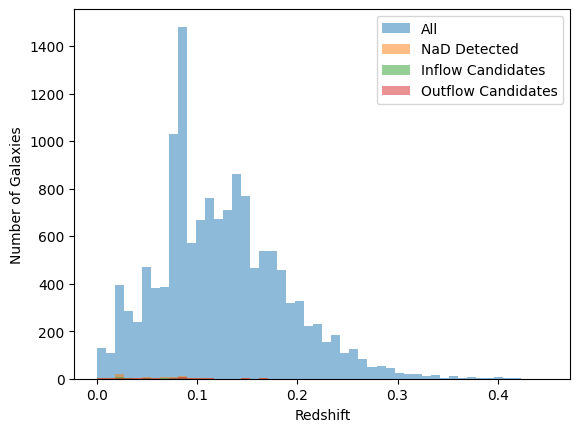

In [78]:
plt.hist(spectrum.z, bins=50, alpha=0.5, label='All', color='C0', range=(0, 0.45))
plt.hist([spectrum.z[spectrum.id2index(id)] for id, _ in NaD], bins=50, alpha=0.5, label='NaD Detected', color='C1', range=(0, 0.45))
plt.hist([spectrum.z[spectrum.id2index(id)] for id, _ in inflow], bins=50, alpha=0.5, label='Inflow Candidates', color='C2', range=(0, 0.45))
plt.hist([spectrum.z[spectrum.id2index(id)] for id, _ in outflow], bins=50, alpha=0.5, label='Outflow Candidates', color='C3', range=(0, 0.45))
plt.xlabel('Redshift')
plt.ylabel('Number of Galaxies')
plt.legend()
plt.savefig('NaD_detection_histogram.png')

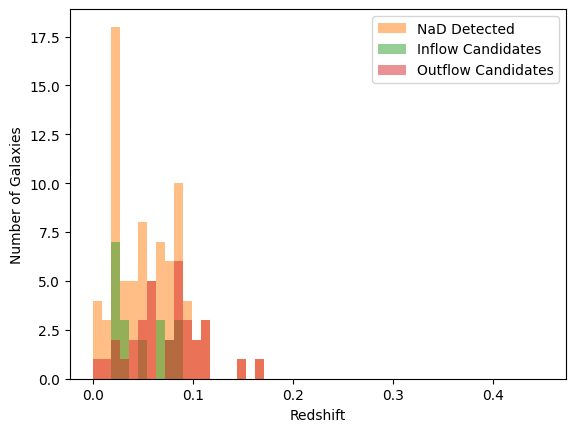

In [79]:
plt.hist([spectrum.z[spectrum.id2index(id)] for id, _ in NaD], bins=50, alpha=0.5, label='NaD Detected', color='C1', range=(0, 0.45))
plt.hist([spectrum.z[spectrum.id2index(id)] for id, _ in inflow], bins=50, alpha=0.5, label='Inflow Candidates', color='C2', range=(0, 0.45))
plt.hist([spectrum.z[spectrum.id2index(id)] for id, _ in outflow], bins=50, alpha=0.5, label='Outflow Candidates', color='C3', range=(0, 0.45))
plt.xlabel('Redshift')
plt.ylabel('Number of Galaxies')
plt.legend()
plt.savefig('NaD_detection_histogram_zoomed.png')

In [22]:
possible_NaD_samples = np.loadtxt('NaD_detection.txt', usecols=(0,1))
possible_inflow_samples = np.loadtxt('inflow_candidates.txt', usecols=(0,1))
possible_outflow_samples = np.loadtxt('outflow_candidates.txt', usecols=(0,1))

In [23]:
print(possible_NaD_samples.shape)
print(possible_inflow_samples.shape)
print(possible_outflow_samples.shape)

(82, 2)
(20, 2)
(33, 2)


In [24]:
sorted_indices = np.argsort(possible_outflow_samples[:, 1])
possible_outflow_samples = possible_outflow_samples[sorted_indices]

sorted_indices = np.argsort(possible_inflow_samples[:, 1])
possible_inflow_samples = possible_inflow_samples[sorted_indices][::-1, :]

In [25]:
# print(possible_outflow_samples[:1,0], spectrum.id2index(possible_outflow_samples[:1,0]))
# print(possible_inflow_samples[:1,0], spectrum.id2index(possible_inflow_samples[:1,0]))



In [152]:
example_targetID = 39627757751112369
example_index = spectrum.id2index(example_targetID)
targetid_example = spectrum.targetID[example_index]

# z = spectrum.z[example_index]
flux = spectrum.coadd_data[example_index]
# vel_grid = lam2vel(desi_wavelength, NaD_rest[0], z=z) / 10
# popt = spectrum.search_NaD(i=example_index, two_component=True)
# sigma_1, sigma_2, dlam, conti_a, conti_b = popt[0], popt[1], popt[-3], popt[-2], popt[-1]
# amp_D1, amp_D2 = popt[2], popt[3]
# amp_D1_free, amp_D2_free = popt[4], popt[5]
# fixed_comp = [(amp_D1, NaD_rest[0]*(1+z), sigma_1), (amp_D2, NaD_rest[1]*(1+z), sigma_1)]
# free_comp  = [(amp_D1_free, (NaD_rest[0]+dlam)*(1+z), sigma_2), (amp_D2_free, (NaD_rest[1]+dlam)*(1+z), sigma_2)]
# conti = model(desi_wavelength, gaussian_parms=None, conti_parms=(conti_a, conti_b))
# fitted_model = model(desi_wavelength, gaussian_parms=(fixed_comp+free_comp), conti_parms=(conti_a, conti_b))
# fixed_comp = model(desi_wavelength, gaussian_parms=fixed_comp, conti_parms=(conti_a, conti_b))
# free_model = model(desi_wavelength, gaussian_parms=free_comp, conti_parms=(conti_a, conti_b))
# ratio_z = flux/conti
# residual_z = flux - fitted_model
# noise = np.std(residual_z)





# fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [5, 1]})
# fig.subplots_adjust(hspace=0)

# axes[0].step(vel_grid, ratio_z, color='k', label='After adjustment', where='mid', alpha=0.5)
# axes[0].plot(vel_grid, fitted_model/conti,
#             color='magenta', label='Fitted Model', linestyle='-', lw=3)
# axes[0].plot(vel_grid, free_model/conti,
#             color='cyan', label='Free Comp', linestyle='--', lw=3)
# axes[0].plot(vel_grid, fixed_comp/conti,
#             color='orange', label='Fixed Comp', linestyle='--', lw=3)
# axes[0].set_ylabel('Normalized Flux')
# axes[0].set_title(f'Spectrum for TARGETID {spectrum.targetID[example_index]}; z={z:.3f}')
# axes[0].set_ylim((0.35, 1.3))
# axes[0].legend()
# axes[0].grid(alpha=0.5, axis='x')

# axes[1].plot(vel_grid, residual_z/conti, color='k', alpha=0.5)
# axes[1].axhline(y=0, color='gray', linestyle=':')
# axes[1].set_ylim((-0.5, 0.5))
# axes[1].set_xlim((-2500, 2500))
# axes[1].set_ylabel('Res')
# axes[1].set_xlabel(r'Rest Velocity (km $s^{-1}$)')
# axes[1].grid(alpha=0.5, axis='x')

# plt.savefig('NaD_example_spectrum.png')

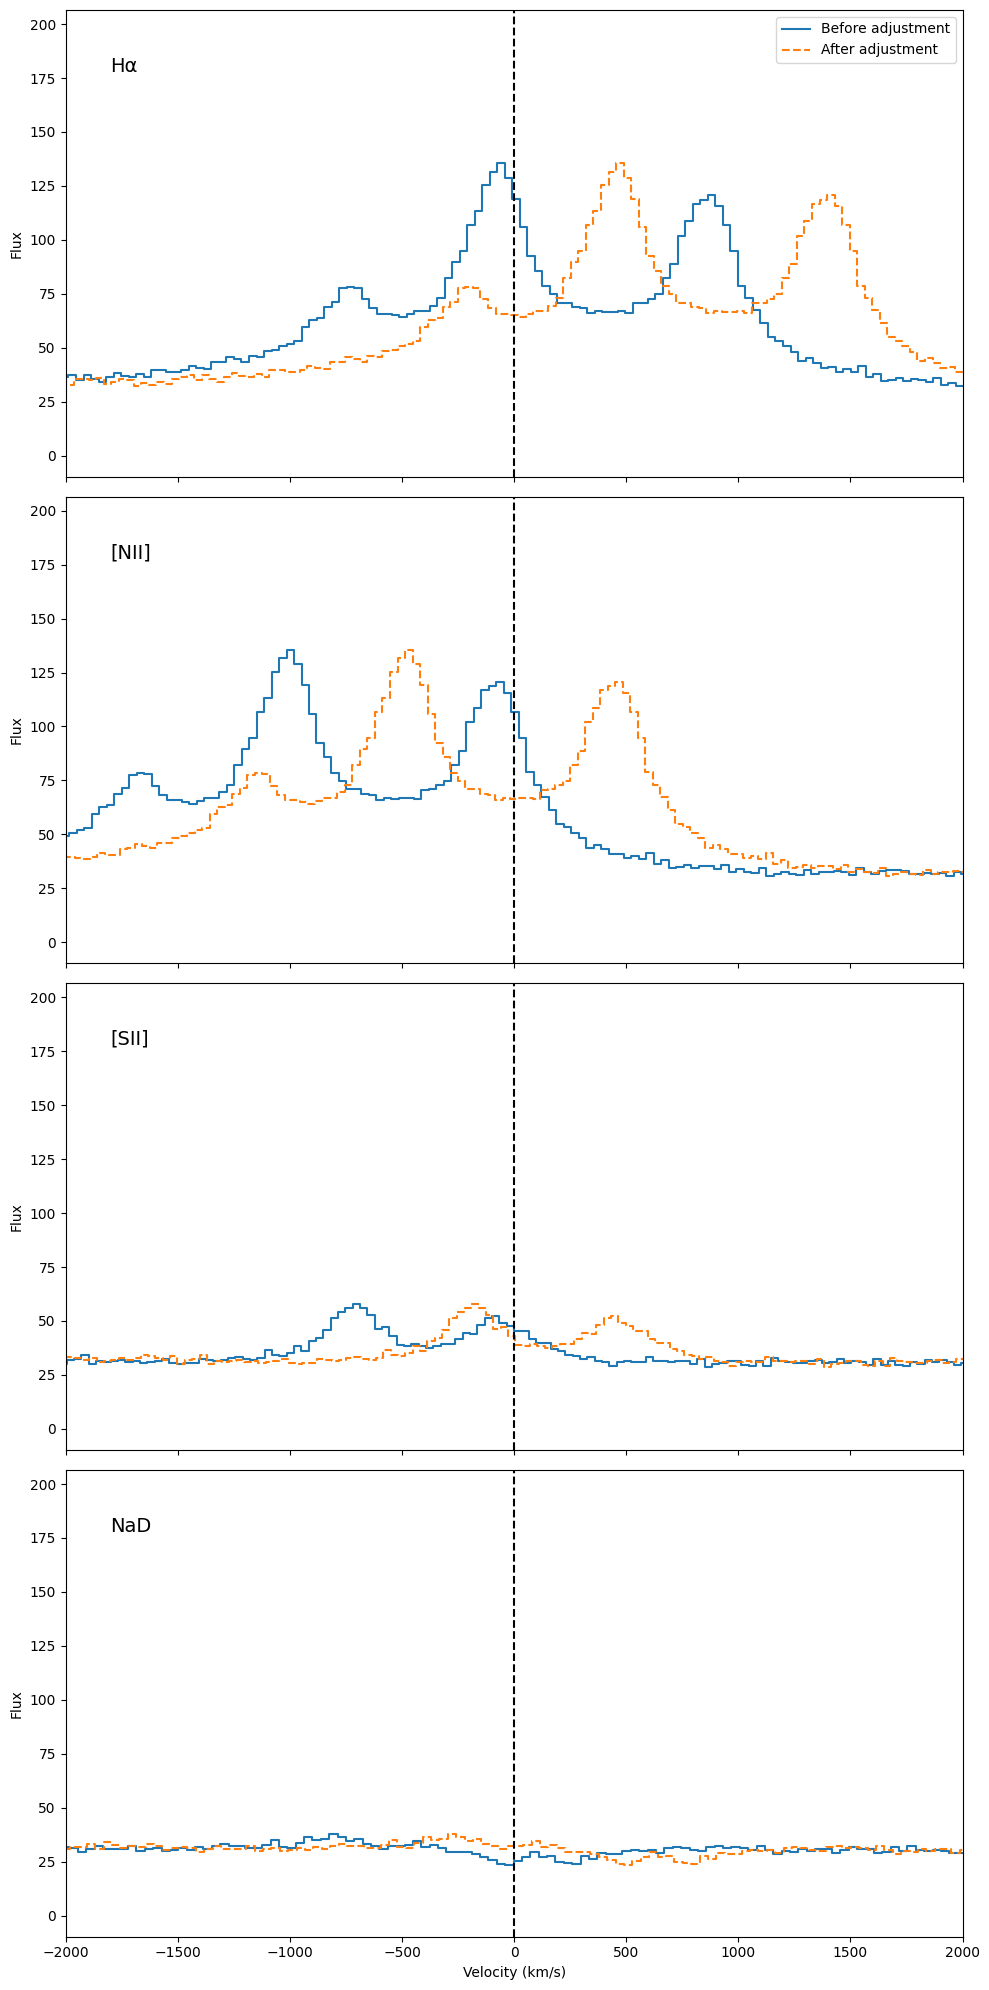

In [153]:
fig, ax = plt.subplots(4, 1, figsize=(10, 20), sharex=True)
z = spectrum.z_pipe[example_index]
ax[0].step(lam2vel(desi_wavelength, Halpha_rest, z)/10, flux, where='mid', label='Before adjustment')
ax[1].step(lam2vel(desi_wavelength, NII_rest[-1], z)/10, flux, where='mid')
ax[2].step(lam2vel(desi_wavelength, SII_rest[-1], z)/10, flux, where='mid')
ax[3].step(lam2vel(desi_wavelength, NaD_rest[0], z)/10, flux, where='mid')

z = spectrum.z[example_index]
ax[0].step(lam2vel(desi_wavelength, Halpha_rest, z)/10, flux, where='mid', linestyle='--', label='After adjustment')
ax[1].step(lam2vel(desi_wavelength, NII_rest[-1], z)/10, flux, where='mid', linestyle='--')
ax[2].step(lam2vel(desi_wavelength, SII_rest[-1], z)/10, flux, where='mid', linestyle='--')
ax[3].step(lam2vel(desi_wavelength, NaD_rest[0], z)/10, flux, where='mid', linestyle='--')

for i in range(4):
    ax[i].text(0.05, 0.9, ['Hα', '[NII]', '[SII]', 'NaD'][i], transform=ax[i].transAxes, fontsize=14, verticalalignment='top')
    ax[i].set_xlim(-2000, 2000)
    ax[i].axvline(0, color='k', linestyle='--')
    ax[i].set_ylabel('Flux')
ax[-1].set_xlabel('Velocity (km/s)')
ax[0].legend()
plt.tight_layout()
plt.savefig('example_spectrum_comparison.png')

In [154]:
# def PlotFit_spectrum(i, show=False, print_fit_result=False):
#     z, targetID, RA, DEC, coadd_data, ivar, mask, resting_lam = extract_spectrum(i)
    
#     resting_lam, coadd_data, ivar = mask_spectrum(resting_lam, coadd_data, ivar, mask)
#     resting_lam, coadd_data, ivar, popt, pcov = fit(resting_lam, coadd_data, ivar)
    
#     velocity_axis = (resting_lam - NaDII) / NaDII * c

#     stellar_continuum = popt[6] * resting_lam + popt[7]


#     residual = coadd_data - two_gaussian_continuum(resting_lam, *popt)

#     extracted_line = coadd_data / stellar_continuum


#     noise = np.std(residual)
    
#     if print_fit_result:
#         print('RA: ', RA, 'DEC: ', DEC)
#         print('FWHM NaD I:', 2 * np.sqrt(2 * np.log(2)) * popt[2])
#         print('FWHM NaD II:', 2 * np.sqrt(2 * np.log(2)) * popt[5])
#         # print('Peak intensity of NaD I:', popt[0])
#         print('S/N ratio of NaD I:', np.abs(popt[0] / noise))
#         # print('Peak intensity of NaD II:', popt[3])
#         print('S/N ratio of NaD II:', np.abs(popt[3] / noise))
    
#     fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [5, 1]})
#     fig.subplots_adjust(hspace=0)

#     # axes[0].plot(velocity_axis, extracted_line, color='k', label='Normalized Flux')
#     axes[0].step(velocity_axis, extracted_line, color='k', label='Normalized Flux', where='mid')
#     axes[0].plot(velocity_axis, two_gaussian_continuum(resting_lam, *popt)/stellar_continuum,
#             color='magenta', label='Fitted Model', linestyle='--', lw=3)
#     axes[0].axhline(y=1, color='gray', linestyle=':')
#     axes[0].axvline(x=(NaDI - NaDII) / NaDII * c, linestyle=':')
#     axes[0].axvline(x=(NaDII - NaDII) / NaDII * c, linestyle=':')
#     axes[0].set_ylabel('Normalized Flux')
#     axes[0].set_title(f'Spectrum for TARGETID {targetID}; z={z:.3f}')
#     axes[0].set_ylim((0.35, 1.3))
#     axes[0].legend()
#     axes[0].grid(alpha=0.5, axis='x')

#     axes[1].plot(velocity_axis, residual/stellar_continuum, color='k', label='Residual')
#     axes[1].axhline(y=0, color='gray', linestyle=':')
#     axes[1].set_xlim((-2500, 2500))
#     axes[1].set_ylabel('Res')
#     axes[1].set_xlabel(r'Rest Velocity (km $s^{-1}$)')
#     axes[1].grid(alpha=0.5, axis='x')

#     plt.savefig(f'./figures/spectra/spectrum_{i}.pdf', transparent=True)
#     plt.savefig(f'./figures/spectra/spectrum_{i}.png')
#     if show:
#         plt.show()
#     else:
#         plt.close('all')
        